In [2]:
import pandas as pd
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("../data/raw/survey.csv")

# Clean age
df = df[(df['Age'] >= 15) & (df['Age'] <= 75)]

# Drop Timestamp column
if 'Timestamp' in df.columns:
    df = df.drop('Timestamp', axis=1)

# Drop missing target
df = df.dropna(subset=['treatment'])

# Convert target
df['treatment'] = df['treatment'].map({'No': 0, 'Yes': 1})

# Fill missing values
for col in df.columns:
    if col != 'treatment':
        df[col] = df[col].fillna(df[col].mode()[0])

# Split X and y
X = df.drop('treatment', axis=1)
y = df['treatment']

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Load your saved best model
model = joblib.load("../models/best_model.pkl")

print("Model and data loaded successfully")
print("X_test shape:", X_test.shape)

Model and data loaded successfully
X_test shape: (251, 332)


Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


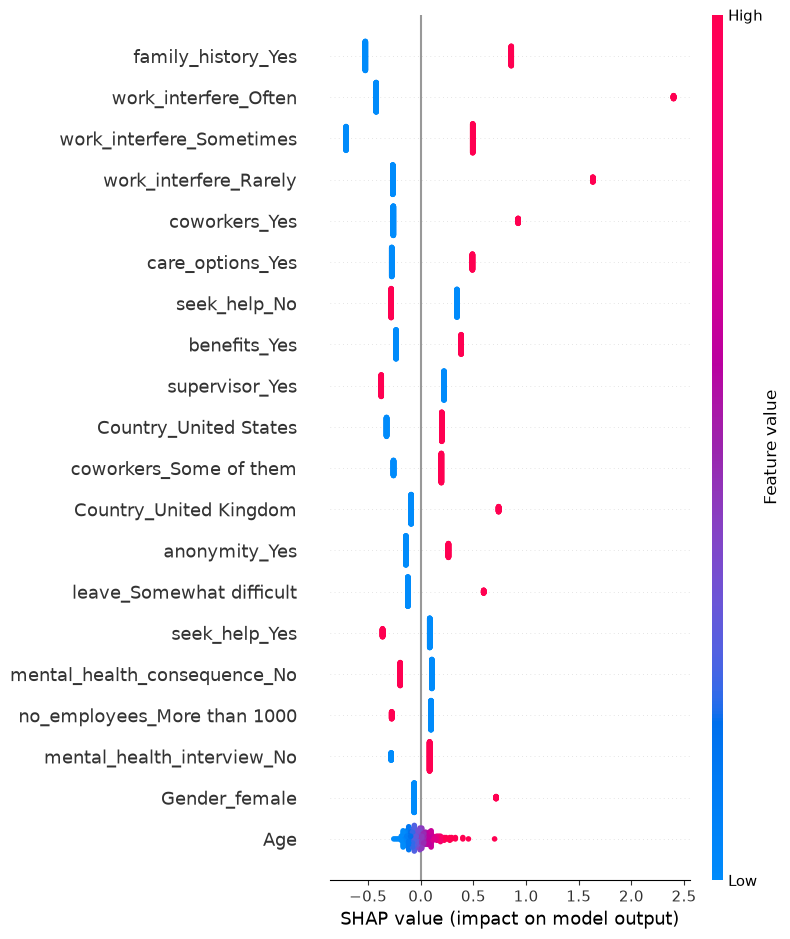

In [4]:
# Convert all features to float for SHAP
X_train_shap = X_train.astype(float)
X_test_shap = X_test.astype(float)

# Create SHAP explainer for Logistic Regression
explainer = shap.LinearExplainer(model, X_train_shap)

# Calculate SHAP values
shap_values = explainer(X_test_shap)

# SHAP summary plot
shap.summary_plot(shap_values.values, X_test_shap)

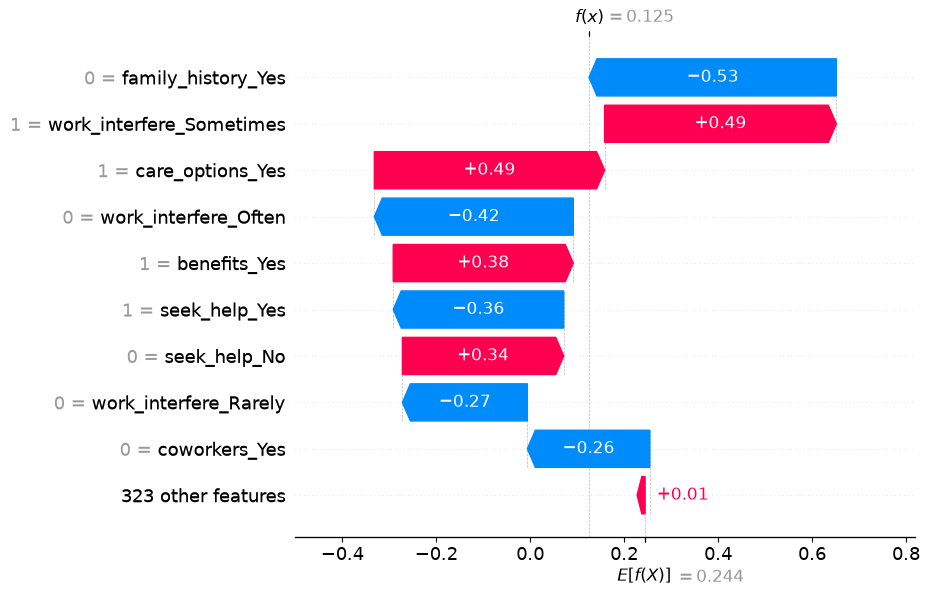

In [5]:
shap.plots.waterfall(shap_values[0])

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


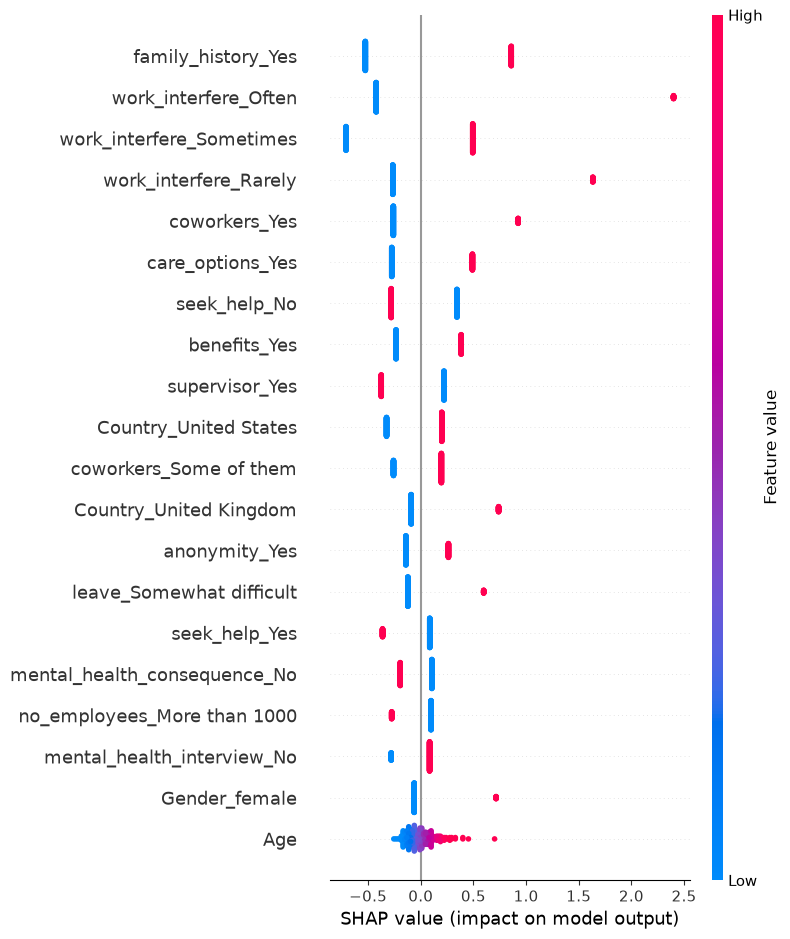

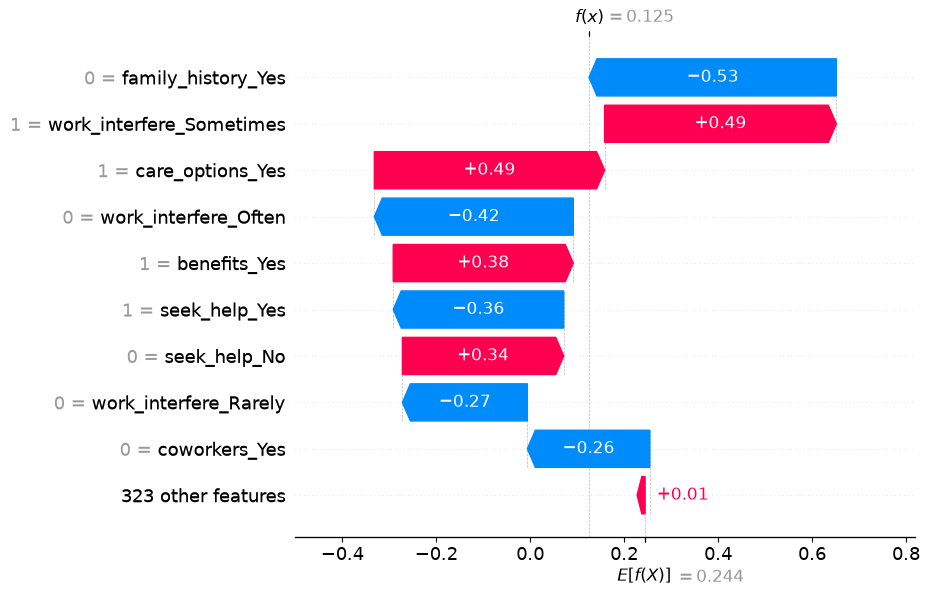

In [6]:
import shap

# Convert boolean/object columns to float
X_train_shap = X_train.astype(float)
X_test_shap = X_test.astype(float)

# SHAP explainer for Logistic Regression
explainer = shap.LinearExplainer(model, X_train_shap)

# Get SHAP values
shap_values = explainer(X_test_shap)

# Global explanation
shap.summary_plot(shap_values.values, X_test_shap)

# Individual explanation
shap.plots.waterfall(shap_values[0])